In [1]:
# Imports

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score,
	precision_score,
	recall_score,
    brier_score_loss,
	confusion_matrix,
    roc_curve,
    precision_recall_curve
)

In [2]:
def compute_metrics(df, threshold=0.7):

    y = df.y_true.values
    p = df.p_pred.values

    y_pred = (p > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

    return {
        "roc_auc": roc_auc_score(y, p),
        "roc": roc_curve(y, p),

        "pr_auc": average_precision_score(y, p),
        "pr": precision_recall_curve(y, p),
        
        "f1": f1_score(y, y_pred),
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "brier": brier_score_loss(y, p),
        "confusion": {
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp)
        },
        "n": len(df)
    }

In [195]:
def confusion_matrix_dataframe(cm):

    return pd.DataFrame(
        [
            [cm["TN"], cm["FP"]],
            [cm["FN"], cm["TP"]],
        ],
        index=["Actual Negative", "Actual Positive"],
        columns=["Predicted Negative", "Predicted Positive"]
    )

In [3]:
def metrics_for(experiment_id=None):
	if experiment_id:
		filename = f"results.{experiment_id}"
	else:
		filename = "results"

	results = json.load(open(f"./data/{filename}.json"))
	df = pd.DataFrame(results)

	metrics = {}

	metrics["overall"] = compute_metrics(df)

	for doc_type in df.doc_type.unique():
		metrics[doc_type] = compute_metrics(df[df.doc_type == doc_type])

	return metrics, df

In [ ]:
# Load metrics

#experiment_id = "baseline_sentence_nli_r1"
#experiment_id = "baseline_sentence_nli_r2"
#experiment_id = "cluster_sentence_nli_r1"
#experiment_id = "cluster_sentence_nli_r2"
#experiment_id = "cluster_sentence_nli_r3"
#experiment_id = "cluster_claims_nli_r1"
#experiment_id = "cluster_claims_nli_r2"
#experiment_id = "cluster_claims_nli_r3"
experiment_id = "cluster_claims_nli_r4"
#experiment_id = "window_sentence_nli_r1"

metrics, df = metrics_for(experiment_id)

In [5]:
output_folder = f"data/{experiment_id}/"
if not os.path.isdir(output_folder):
	os.makedirs(output_folder)

In [199]:
# Results overview table

table = pd.DataFrame(metrics).T

table.drop(columns=['confusion', 'roc', 'pr'], inplace=True)

table = table.astype({ 'n': int })

latex = table.to_latex(
    float_format="%.3f",
    caption="Contradiction detection performance",
    label="tab:results",

)

with open(f"{output_folder}/results.tex", "w") as f:
    f.write(latex)

print(latex)

table

\begin{table}
\caption{Contradiction detection performance}
\label{tab:results}
\begin{tabular}{llllllllr}
\toprule
 & roc_auc & pr_auc & f1 & accuracy & precision & recall & brier & n \\
\midrule
overall & 0.583 & 0.583 & 0.602 & 0.556 & 0.548 & 0.668 & 0.346 & 891 \\
wiki & 0.648 & 0.641 & 0.676 & 0.593 & 0.568 & 0.833 & 0.361 & 295 \\
news & 0.603 & 0.625 & 0.551 & 0.567 & 0.580 & 0.525 & 0.301 & 312 \\
story & 0.498 & 0.489 & 0.566 & 0.504 & 0.500 & 0.652 & 0.379 & 284 \\
\bottomrule
\end{tabular}
\end{table}



,roc_auc,pr_auc,f1,accuracy,precision,recall,brier,n
overall,0.582622,0.582512,0.60241,0.555556,0.548446,0.668151,0.345635,891
wiki,0.647632,0.640595,0.675676,0.59322,0.568182,0.833333,0.360923,295
news,0.603321,0.624738,0.551495,0.567308,0.58042,0.525316,0.30063,312
story,0.497545,0.489413,0.566154,0.503521,0.5,0.652482,0.379197,284


In [200]:
# Confusion matrix table per doc type

for doc_type in metrics.keys():
    cm_df = confusion_matrix_dataframe(metrics[doc_type]['confusion'])
    latex = cm_df.to_latex(
        caption=f"Confusion matrix for contradiction detection ({doc_type})",
        label="tab:confusion_matrix"
    )

    with open(f"{output_folder}/cm_{doc_type}.tex", "w") as f:
        f.write(latex)

    print(latex)
    print()

\begin{table}
\caption{Confusion matrix for contradiction detection (overall)}
\label{tab:confusion_matrix}
\begin{tabular}{lrr}
\toprule
 & Predicted Negative & Predicted Positive \\
\midrule
Actual Negative & 195 & 247 \\
Actual Positive & 149 & 300 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}
\caption{Confusion matrix for contradiction detection (wiki)}
\label{tab:confusion_matrix}
\begin{tabular}{lrr}
\toprule
 & Predicted Negative & Predicted Positive \\
\midrule
Actual Negative & 50 & 95 \\
Actual Positive & 25 & 125 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}
\caption{Confusion matrix for contradiction detection (news)}
\label{tab:confusion_matrix}
\begin{tabular}{lrr}
\toprule
 & Predicted Negative & Predicted Positive \\
\midrule
Actual Negative & 94 & 60 \\
Actual Positive & 75 & 83 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}
\caption{Confusion matrix for contradiction detection (story)}
\label{tab:confusion_matrix}
\begin{tabular}{lrr}
\

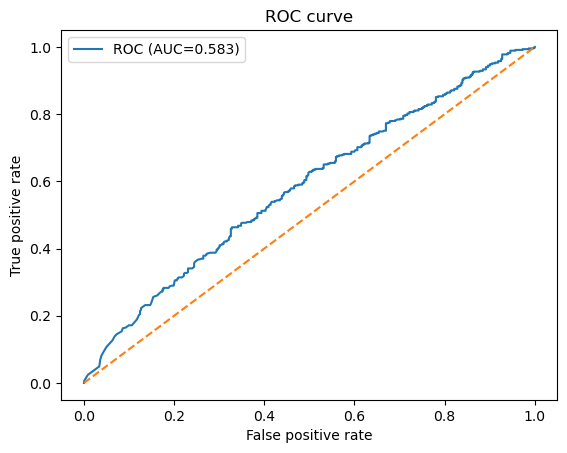

In [201]:
# ROC curve

fpr, tpr, _ = metrics["overall"]["roc"]

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC={metrics['overall']['roc_auc']:.3})")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend()

plt.savefig(f"{output_folder}/roc.jpg")

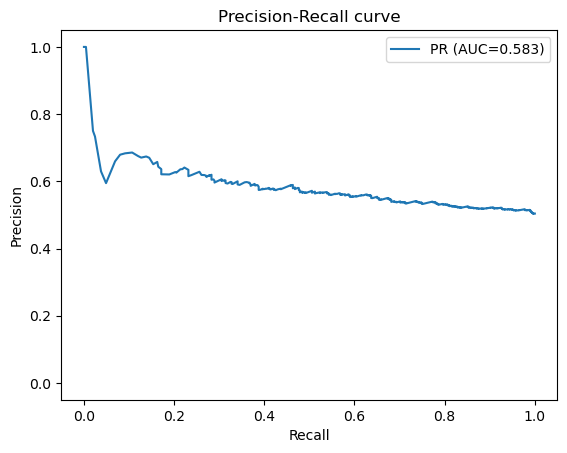

In [202]:
# Precision-Recall curve

prec, rec, _ = metrics['overall']['pr']

plt.figure()
plt.plot(rec, prec, label=f"PR (AUC={metrics['overall']['pr_auc']:.3})")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.legend()

plt.savefig(f"{output_folder}/pr.jpg")

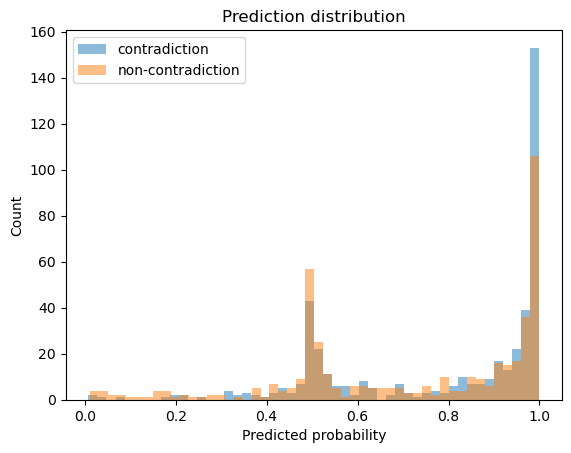

In [203]:
# Prediction distribution histogram

plt.figure()

plt.hist(df[df.y_true==1].p_pred, bins=50, alpha=0.5, label="contradiction")
plt.hist(df[df.y_true==0].p_pred, bins=50, alpha=0.5, label="non-contradiction")

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Prediction distribution")
plt.legend()

plt.savefig(f"{output_folder}/histogram.jpg")

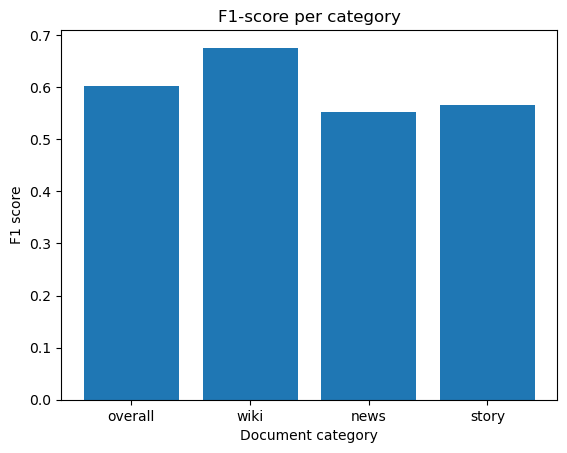

In [204]:
# F1 per category graph

cats = list(metrics.keys())
f1_scores = [metrics[c]["f1"] for c in cats]

plt.figure()
plt.bar(cats, f1_scores)
plt.ylabel("F1 score")
plt.xlabel("Document category")
plt.title("F1-score per category")

plt.savefig(f"{output_folder}/categories.jpg")

# Analysis: per contra_type

In [22]:
# Load data and prepare One-vs-Clean labels

RESULTS_FILE = "./data/results.cluster_sentence_nli_r2.json"
CONTRADOC_FILE = "./datasets/ContraDoc/ContraDoc.json"
EXPERIMENT_ID = "cluster_sentence_nli_r2"
THRESHOLD = 0.7

# Load model output (independent of experiment choice in cell 5).
results_df = pd.DataFrame(json.load(open(RESULTS_FILE)))

# Load ContraDoc and map unique_id -> contra_type.
contradoc = json.load(open(CONTRADOC_FILE))
contra_rows = []
for split in ["pos", "neg"]:
    for _, item in contradoc.get(split, {}).items():
        uid = item.get("unique id")
        ctype = item.get("contra_type", [])
        if uid is not None:
            contra_rows.append({"unique_id": uid, "contra_type": ctype})

contra_df = pd.DataFrame(contra_rows).drop_duplicates(subset=["unique_id"])
merged = results_df.merge(contra_df, on="unique_id", how="left")
merged["contra_type"] = merged["contra_type"].apply(
    lambda x: x if isinstance(x, list) else []
)

# Clean = non-contradiction
clean_mask = (merged["y_true"] == 0) & (merged["contra_type"].apply(len) == 0)
if clean_mask.sum() == 0:
    clean_mask = merged["y_true"] == 0

all_types = sorted({t for types in merged["contra_type"] for t in types})
print(f"Number of contra_types: {len(all_types)}")
print(f"Number of clean samples: {int(clean_mask.sum())}")

Number of contra_types: 9
Number of clean samples: 441


In [23]:
# Metrics per contra_type (One-vs-Clean)

rows = []
pr_curves_by_type = {}

for ctype in all_types:
    pos_mask = merged["contra_type"].apply(lambda types: ctype in types)
    eval_df = merged[pos_mask | clean_mask].copy()

    y_bin = pos_mask[pos_mask | clean_mask].astype(int).values
    p = eval_df["p_pred"].values
    y_pred = (p > THRESHOLD).astype(int)

    if len(np.unique(y_bin)) < 2:
        continue

    pr_auc = average_precision_score(y_bin, p)
    precision, recall, _ = precision_recall_curve(y_bin, p)

    pr_curves_by_type[ctype] = {
        "precision": precision,
        "recall": recall,
        "pr_auc": pr_auc,
        "n_positive": int(y_bin.sum()),
        "n_clean": int((y_bin == 0).sum())
    }

    rows.append({
        "contra_type": ctype,
        "f1": f1_score(y_bin, y_pred, zero_division=0),
        "pr_auc": pr_auc,
        "n_positive": int(y_bin.sum()),
        "n_clean": int((y_bin == 0).sum())
    })

metrics_by_type = pd.DataFrame(rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
metrics_by_type

,contra_type,f1,pr_auc,n_positive,n_clean
0,Content,0.570667,0.585956,288,441
1,Negation,0.353808,0.457082,87,441
2,Numeric,0.270718,0.378563,65,441
3,Emotion/Mood/Feeling,0.321608,0.282892,86,441
4,Perspective/View/Opinion,0.305825,0.246439,101,441
5,Factual,0.218289,0.222802,54,441
6,Relation,0.130137,0.125270,25,441
7,Causal,0.179487,0.106516,36,441
8,Other,0.008000,0.005000,1,441


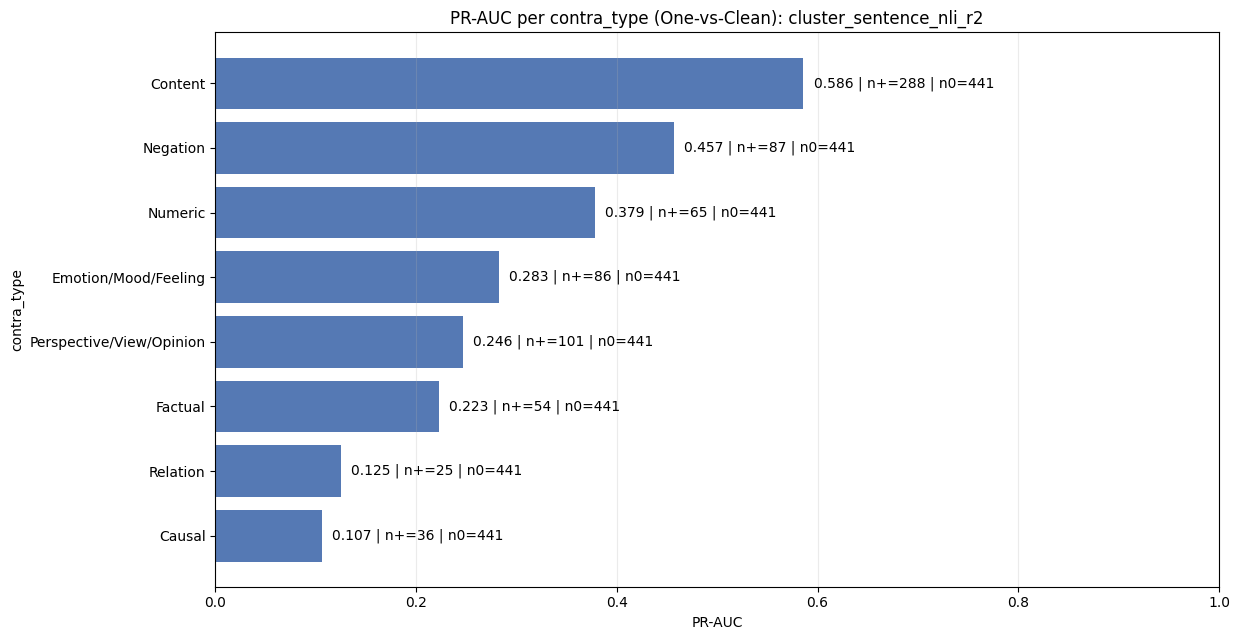

In [24]:
# PR-AUC chart per contra_type (without Other)

plot_df = metrics_by_type[metrics_by_type["contra_type"].str.lower() != "other"]
plot_df = plot_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12.5, 6.5))
plt.barh(plot_df["contra_type"], plot_df["pr_auc"], color="#4C72B0", alpha=0.95)
plt.gca().invert_yaxis()
plt.xlim(0, 1)
plt.xlabel("PR-AUC")
plt.ylabel("contra_type")
plt.title(f"PR-AUC per contra_type (One-vs-Clean): {EXPERIMENT_ID}")
plt.grid(axis="x", alpha=0.25)

for i, row in plot_df.iterrows():
    value = row["pr_auc"]
    label = f"{value:.3f} | n+={int(row['n_positive'])} | n0={int(row['n_clean'])}"
    x = min(value + 0.01, 0.98)
    plt.text(x, i, label, va="center", ha="left", fontsize=10)

plt.tight_layout()
plt.savefig(f"data/pr_auc_{EXPERIMENT_ID}_one_vs_clean_by_contra_type.png", dpi=300)
plt.show()

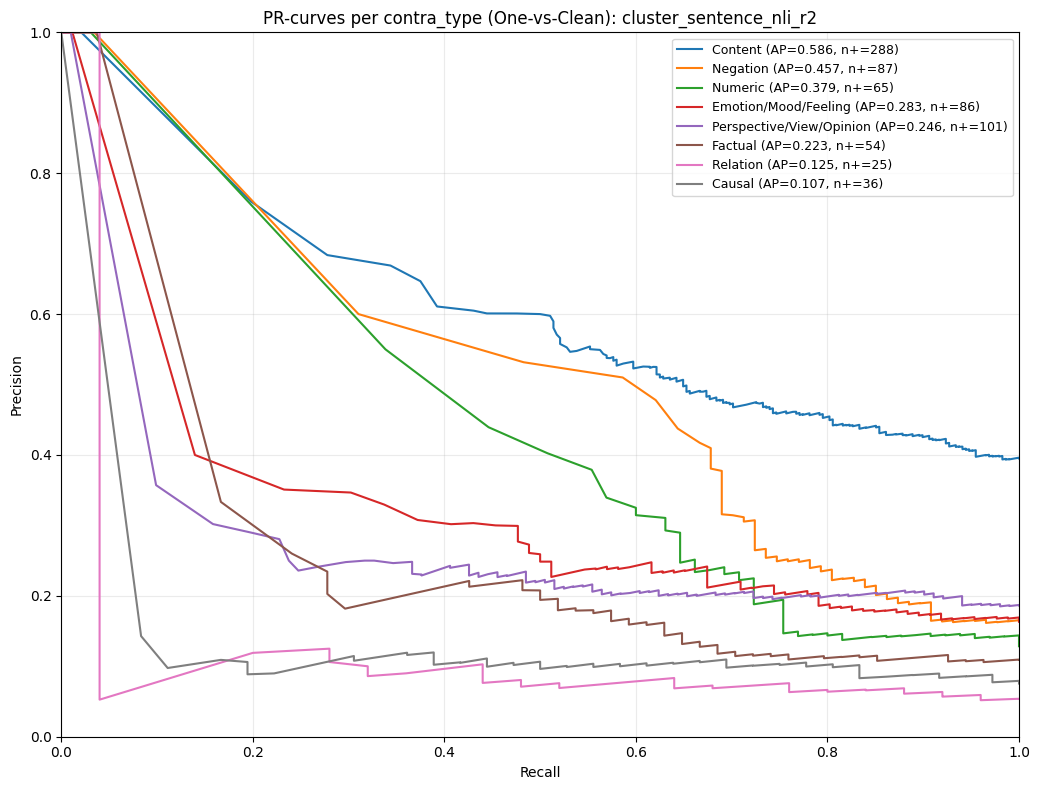

In [25]:
# PR curves per contra_type (without Other)

plot_df = metrics_by_type[metrics_by_type["contra_type"].str.lower() != "other"]
plot_df = plot_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10.5, 8))
for _, row in plot_df.iterrows():
    ctype = row["contra_type"]
    curve = pr_curves_by_type[ctype]
    plt.plot(
        curve["recall"],
        curve["precision"],
        label=f"{ctype} (AP={curve['pr_auc']:.3f}, n+={curve['n_positive']})"
    )

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR-curves per contra_type (One-vs-Clean): {EXPERIMENT_ID}")
plt.grid(alpha=0.25)
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(f"data/pr_curves_{EXPERIMENT_ID}_one_vs_clean_by_contra_type.png", dpi=300)
plt.show()